In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
from scipy.spatial.distance import cdist

sys.path.append(r"D:/Football Project/src")

import feature_lists as fl

### I have concluded from the previous smaller database that average produces better clusters ###

In [2]:
df_avg=pd.read_csv('../../../data/processed/major_leagues/Forwards/Avg_Major_Forwards.csv')

In [3]:
df_avg.head()

,player id,player,team id,team,league,position,number_of_seasons,appearances,matchesstarted,minutesplayed,...,bigchancescreated_per90_zscore,goalconversionpercentage_zscore,expectedassists_per90_zscore,totalduelswonpercentage_zscore,penaltyconversion_zscore,shots_on_target_pct_zscore,inaccuratepasses_per90_zscore,offsides_per90_zscore,xa_per_keypass_zscore,accurateownhalfpasses_per90_zscore
0,750,Cristiano Ronaldo,23400,Al-Nassr,Saudi Arabia Pro League,Forwards,3,30.000000,29.666667,2597.333333,...,0.522006,0.449548,-0.160235,-0.320019,1.119170,0.099485,-0.502362,2.994651,-0.098327,-0.223539
1,3306,Karim Benzema,21895,Al-Hilal,Saudi Arabia Pro League,Forwards,3,24.666667,24.333333,2063.333333,...,1.840339,0.429707,0.217562,-0.265886,-0.082202,1.128761,1.091165,0.193323,0.273277,-0.081037
2,12994,Lionel Messi,337602,Inter Miami CF,USA MLS,Forwards,3,23.333333,21.333333,1986.333333,...,2.916466,0.402917,3.804295,1.104056,1.053863,0.233152,2.241020,0.062034,1.342368,0.742246
3,19356,Iago Aspas,2821,Celta Vigo,Spain La Liga,Forwards,3,32.333333,20.333333,1872.333333,...,2.466714,0.223262,2.589433,1.054958,1.070530,0.121138,2.682376,-1.093576,0.556120,1.654639
4,33902,Danny Welbeck,30,Brighton & Hove Albion,England Premier League,Forwards,3,32.000000,23.666667,2031.000000,...,-0.606903,0.456949,-0.620094,0.461254,0.299563,0.297256,-1.106733,-0.626390,-0.756859,0.697681


In [4]:
X_avg=df_avg.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons','appearances','matchesstarted'])

In [5]:
X_avg.shape

(867, 54)

In [6]:
scaler = StandardScaler()
X_avg_scaled = scaler.fit_transform(X_avg)

In [7]:
inertia_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

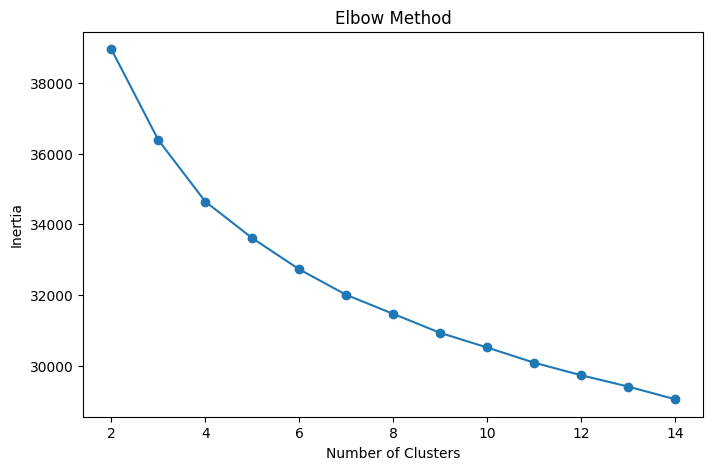

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [9]:
scores_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_avg_scaled)
    
    score = silhouette_score(X_avg_scaled, labels)
    scores_avg.append(score)

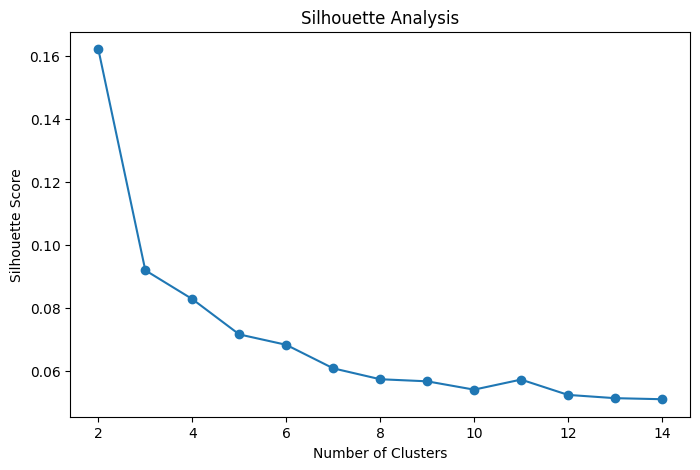

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [11]:
x=5
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_avg_scaled)

df_avg[f"cluster_{x}"] = labels

In [12]:
cluster_avg_summary = (df_avg.drop(columns=fl.metadata_features).groupby(f"cluster_{x}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_avg_summary.transpose())

cluster_5,0,1,2,3,4
number_of_seasons,2.264286,1.947917,2.051643,2.030151,2.455285
appearances,28.275000,27.893229,28.115023,28.635678,28.743902
matchesstarted,21.047619,18.367188,19.978091,18.381910,21.478320
minutesplayed,1853.361905,1642.550347,1764.832551,1680.398660,1885.605691
dispossessed_per_touch_zscore,0.137225,-0.151267,0.038457,0.535646,-0.671889
groundduelswon_per90_zscore,-0.716917,0.943503,-0.461462,-0.171282,0.717842
keypasses_per90_zscore,-0.346983,0.162690,-0.379937,-0.412335,1.516479
expectedgoals_per90_zscore,0.990681,-0.673856,0.087115,-0.034031,-0.207342
accuratecrossespercentage_zscore,-0.126926,0.147306,-0.121813,-0.278669,0.354001
totalduelswon_per90_zscore,-0.356208,0.268035,-0.633555,0.896830,-0.145653


In [13]:
pca = PCA(n_components=2)

X_avg_pca = pca.fit_transform(X_avg_scaled)

df_avg["PC1"] = X_avg_pca[:,0]
df_avg["PC2"] = X_avg_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"cluster_{x}",
    hover_name='player',         
    hover_data=['team','appearances','minutesplayed'], 
    title=f"Forwards Avg Clusters (K={x})",
    width=1000,
    height=700
)

fig.show()

### 5 cluster seems to be correct for this due to the seperation ###

### Interesting to see both Messi and Ronaldo still overperforming in their Leagues at such a Level ###

In [14]:
df_avg[f"cluster_{x}"].value_counts()

cluster_5
2    213
3    199
1    192
0    140
4    123
Name: count, dtype: int64

In [15]:
pca = PCA()

X_pca = pca.fit_transform(X_avg_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [16]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [17]:
pca_sizes = range(13,20)

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_avg_scaled)

In [18]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(4, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [19]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
0,13,4,0.115364
7,14,4,0.111567
14,15,4,0.109410
21,16,4,0.106738
28,17,4,0.104067
35,18,4,0.101858
1,13,5,0.100618
42,19,4,0.099797
8,14,5,0.097955
15,15,5,0.095789


In [20]:
x=13
pca = PCA(n_components=x)
X_pca = pca.fit_transform(X_avg_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_avg.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(x)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
dispossessed_per_touch_zscore,-0.102114,-0.128201,0.171370,-0.263033,0.253727,-0.032112,-0.098305,0.027712,0.099545,0.165766,-0.102391,0.022375,0.070649
groundduelswon_per90_zscore,0.209152,-0.056248,0.186834,0.008813,0.206216,0.042493,-0.195001,-0.029711,0.001473,-0.081545,0.068914,0.077544,0.007288
keypasses_per90_zscore,0.199656,0.166932,0.095498,-0.037032,-0.103206,0.012403,0.051733,-0.080850,0.029086,0.089152,-0.145279,-0.168194,-0.134068
expectedgoals_per90_zscore,-0.172950,0.193484,0.118164,0.015690,-0.054513,-0.020717,-0.139566,-0.050471,0.073313,0.035242,0.114219,0.024550,-0.040720
accuratecrossespercentage_zscore,0.085295,0.047123,-0.012213,0.001359,-0.091252,-0.035099,0.118869,-0.095573,0.049306,0.003836,-0.230040,0.072089,0.573822
totalduelswon_per90_zscore,0.042367,-0.174521,0.357600,0.221617,0.085977,0.083638,0.033926,-0.042185,0.014750,-0.010281,-0.005574,0.029667,0.000921
successfuldribbles_per90_zscore,0.188111,0.021398,0.157906,-0.112157,0.170710,-0.036892,-0.146622,-0.117290,-0.068378,0.036957,0.078789,-0.057719,0.062383
bigchancesmissed_per90_zscore,-0.191793,0.073895,0.123570,-0.038626,-0.178566,-0.027052,-0.177329,-0.062585,-0.027063,0.040319,0.136744,0.002531,-0.047889
leftfootgoals_per90_zscore,-0.034736,0.157283,0.057815,-0.009545,0.008818,0.005590,-0.002163,-0.006219,-0.255824,0.343324,-0.118250,0.576124,-0.104566
ballrecovery_per90_zscore,0.242057,-0.020075,0.025656,-0.016265,0.091400,-0.029634,0.018153,0.066504,0.042574,0.029893,0.226672,0.013646,0.004806


In [21]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
ballrecovery_per90_zscore                0.242057
accuratefinalthirdpasses_per90_zscore    0.215903
accuratecrosses_per90_zscore             0.214864
groundduelswon_per90_zscore              0.209152
possessionlost_per90_zscore              0.203053
keypasses_per90_zscore                   0.199656
accurateownhalfpasses_per90_zscore       0.196238
shotsfrominsidethebox_per90_zscore       0.194100
defensive_actions_zscore                 0.192362
bigchancesmissed_per90_zscore            0.191793
Name: PC1, dtype: float64

PC2
goals_per90_zscore                 0.274671
shotsontarget_per90_zscore         0.255791
rightfootgoals_per90_zscore        0.217281
duellost_per90_zscore              0.210846
scoringfrequency_zscore            0.210004
penaltygoals_per90_zscore          0.207158
goalconversionpercentage_zscore    0.201348
expectedgoals_per90_zscore         0.193484
goals_minus_xg_per90_zscore        0.186331
penaltyconversion_zscore           0.183103
Name: PC2, dtype: float6

In [22]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(x)]
)

In [23]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [24]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [25]:
cluster=4

kmeans_pca = KMeans(n_clusters=cluster, random_state=42, n_init=20)
df_avg[f'pca_cluster_{cluster}'] = kmeans_pca.fit_predict(X_pca)

cluster_summary = (df_avg.drop(columns=fl.metadata_features+['cluster_5','PC1','PC2',]).groupby(f"pca_cluster_{cluster}").mean())

display(cluster_summary.transpose())

pca_cluster_4,0,1,2,3
number_of_seasons,1.957143,2.058366,2.141818,2.440000
appearances,28.088889,28.445525,28.100606,28.797333
matchesstarted,18.612698,18.470817,20.672121,21.502667
minutesplayed,1662.409524,1674.106355,1824.385455,1888.169333
dispossessed_per_touch_zscore,-0.176952,0.527966,0.032138,-0.680436
groundduelswon_per90_zscore,0.872174,-0.174533,-0.683206,0.690259
keypasses_per90_zscore,0.164102,-0.421479,-0.388422,1.495034
expectedgoals_per90_zscore,-0.643036,-0.058677,0.614530,-0.186263
accuratecrossespercentage_zscore,0.130451,-0.196501,-0.176852,0.355154
totalduelswon_per90_zscore,0.185617,0.640662,-0.568089,-0.161638


In [26]:
df_avg["PC1"] = X_pca[:,0]
df_avg["PC2"] = X_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"pca_cluster_4",
    hover_name='player',         
    hover_data=['team','minutesplayed','number_of_seasons'], 
    title=f"Striker Clusters (K={cluster})",
    width=1000,
    height=700
)

fig.show()

### 5th Cluster seemed to be just the average player Cluster so I switched to 4 Clusters ###

In [27]:
y=cluster
distances = cdist(X_pca, kmeans_pca.cluster_centers_)

for cluster in range(cluster):

    members = df_avg[df_avg[f"pca_cluster_{y}"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:20]]
    
    print('cluster number-' ,cluster)

    print(df_avg.loc[closest_idx, ["player","team"]])

cluster number- 0
                    player                    team
347           Mousa Tamari           Stade Rennais
221         Hattan Bahebri              Al-Kholood
627        Mohamed Ali Cho                    Nice
436         Mateusz Bogusz          Houston Dynamo
157          Marius Bülter              1. FC Köln
124                  Jason                Al-Fayha
510         Gustav Isaksen                   Lazio
350      Gabriel Strefezza                   Parma
237            Marco Grüll        SV Werder Bremen
588          Diego Collado        Cultural Leonesa
386        Jorge de Frutos          Rayo Vallecano
463  Cheick Tidiane Sabaly                    Metz
734              Leo Sauer               Feyenoord
634            Johan Gomez  Eintracht Braunschweig
558          Ansgar Knauff     Eintracht Frankfurt
257           Dario Špikić                 Rio Ave
366    Christopher Lungoyi            Gaziantep FK
485          Lucas Beltrán                Valencia
758        Vi

In [28]:
cluster_mapping = {
    0: "Ball-Carrying Forward",
    1: "Physical Center-Forward",
    2: "Finisher",
    3: "Creative Forward"
}

df_avg['cluster']=df_avg['pca_cluster_4']
df_avg=df_avg.drop(columns=['cluster_5','pca_cluster_4'])
df_avg['cluster_name']=df_avg["cluster"].map(cluster_mapping)

In [29]:
df_avg.to_csv('../../../data/processed/major_leagues/Forwards/Avg_Major_Forwards_Clustered.csv',index=False)

df_ewma=pd.read_csv('../../../data/processed/major_leagues/Forwards/EWMA_Major_Forwards.csv')


In [30]:
import joblib

In [31]:
joblib.dump(scaler, "../../../models/major_leagues/Forwards/scaler.pkl")
joblib.dump(pca, "../../../models/major_leagues/Forwards/pca.pkl")
joblib.dump(kmeans_pca, "../../../models/major_leagues/Forwards/kmeans.pkl")

['../../../models/major_leagues/Forwards/kmeans.pkl']

In [32]:
X_pca_avg = pca.transform(X_avg_scaled)
pca_cols = [f'PC{i+1}' for i in range(13)]
df_coords_avg = pd.DataFrame(X_pca_avg, columns=pca_cols, index=df_avg.index)

df_avg_clustered = pd.concat([df_avg, df_coords_avg], axis=1)
df_avg_clustered['cluster'] = kmeans_pca.labels_
df_avg_clustered['cluster_name'] = df_avg_clustered['cluster'].map(cluster_mapping)

df_avg_clustered.to_csv('../../../data/processed/major_leagues/Forwards/Avg_Major_Forwards_Clustered.csv', index=False)

In [33]:
X_ewma=df_ewma.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons','appearances','matchesstarted'])

X_scaled_ewma = scaler.transform(X_ewma)
X_pca_ewma = pca.transform(X_scaled_ewma)

pca_cols = [f'PC{i+1}' for i in range(13)]
df_coords_ewma = pd.DataFrame(X_pca_ewma, columns=pca_cols, index=df_ewma.index)

df_ewma_clustered = pd.concat([df_ewma, df_coords_ewma], axis=1)

df_ewma_clustered['cluster']=df_avg['cluster']
df_ewma_clustered['cluster_name']=df_avg['cluster_name']

df_ewma_clustered.to_csv('../../../data/processed/major_leagues/Forwards/EWMA_Major_Forwards_Clustered.csv', index=False)


### Succesfully made 4 clusters for forwards ###